In [26]:
import json

with open("data/downloads/infiniteBench/longbook_choice_eng.jsonl", encoding="utf-8") as f:
    data = [json.loads(line) for line in f]

In [2]:
import os
import streamlit as st

def get_diff_line(old_file, new_file):
    with open(old_file, 'r', encoding='utf-8') as f1, open(new_file, 'r', encoding='utf-8') as f2:
        old_lines = f1.readlines()
        new_lines = f2.readlines()

    max_len = max(len(old_lines), len(new_lines))

    for i in range(max_len):
        a = old_lines[i].rstrip("\n") if i < len(old_lines) else ""
        b = new_lines[i].rstrip("\n") if i < len(new_lines) else ""
        if a != b:
            return i + 1
    return None


def collect_diffs(old_root, new_root):
    diffs = []

    for dirpath, _, files in os.walk(old_root):
        rel = os.path.relpath(dirpath, old_root)
        new_dir = os.path.join(new_root, rel)

        for file in files:
            if not file.endswith(".txt"):
                continue

            old_file = os.path.join(dirpath, file)
            new_file = os.path.join(new_dir, file)

            if not os.path.exists(new_file):
                continue

            diff_line = get_diff_line(old_file, new_file)

            if diff_line is not None:
                diffs.append({
                    "name": f"{rel}/{file}",
                    "old": old_file,
                    "new": new_file,
                    "line": diff_line
                })

    return diffs


st.title("TXT Diff Viewer")

old_root = "Books_old"
new_root = "Books_new"

diffs = collect_diffs(old_root, new_root)

if "selected" not in st.session_state:
    st.session_state.selected = None

st.subheader("Pliki z różnicami")

for i, d in enumerate(diffs):
    if st.button(f"{d['name']} (linia {d['line']})", key=i):
        st.session_state.selected = d

st.divider()

if st.session_state.selected:
    d = st.session_state.selected

    col1, col2 = st.columns(2)

    with open(d["old"], "r", encoding="utf-8") as f:
        old_text = f.read()

    with open(d["new"], "r", encoding="utf-8") as f:
        new_text = f.read()

    with col1:
        st.subheader("Books_old")
        st.text_area("old", old_text, height=600)

    with col2:
        st.subheader("Books_new")
        st.text_area("new", new_text, height=600)

2026-05-17 23:56:31.790 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 23:56:31.842 
  command:

    streamlit run /home/mahuk/chunking-thesis/.venv/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-05-17 23:56:31.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 23:56:31.843 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 23:56:32.715 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 23:56:32.715 Session state does not function when running a script without `streamlit run`
2026-05-17 23:56:32.715 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 23:56:32.716 Thread 'MainThread': missin

Dostępne (chunker, params): [('sequential_hac', 'liberal'), ('max_min', 'liberal'), ('recursive_semantic', 'paper_based'), ('fixed_size', 'fs_512_64_token'), ('fixed_size', 'fs_512_64_char')]

SPLIT POINTS ANALYSIS

Analiza: sequential_hac | liberal
Dostępne splity dla (sequential_hac, liberal): {'example'}

Analiza: max_min | liberal
Dostępne splity dla (max_min, liberal): {'example'}

Analiza: recursive_semantic | paper_based
Dostępne splity dla (recursive_semantic, paper_based): {'example'}

Analiza: fixed_size | fs_512_64_token
Dostępne splity dla (fixed_size, fs_512_64_token): {'example'}

Analiza: fixed_size | fs_512_64_char
Dostępne splity dla (fixed_size, fs_512_64_char): {'example'}
                                       h2  pre     h1  h4     h3  h5      p  \
chunker            params                                                     
sequential_hac     liberal          100.0  NaN  100.0 NaN  100.0 NaN  70.11   
max_min            liberal          100.0  NaN  100.0 NaN  100

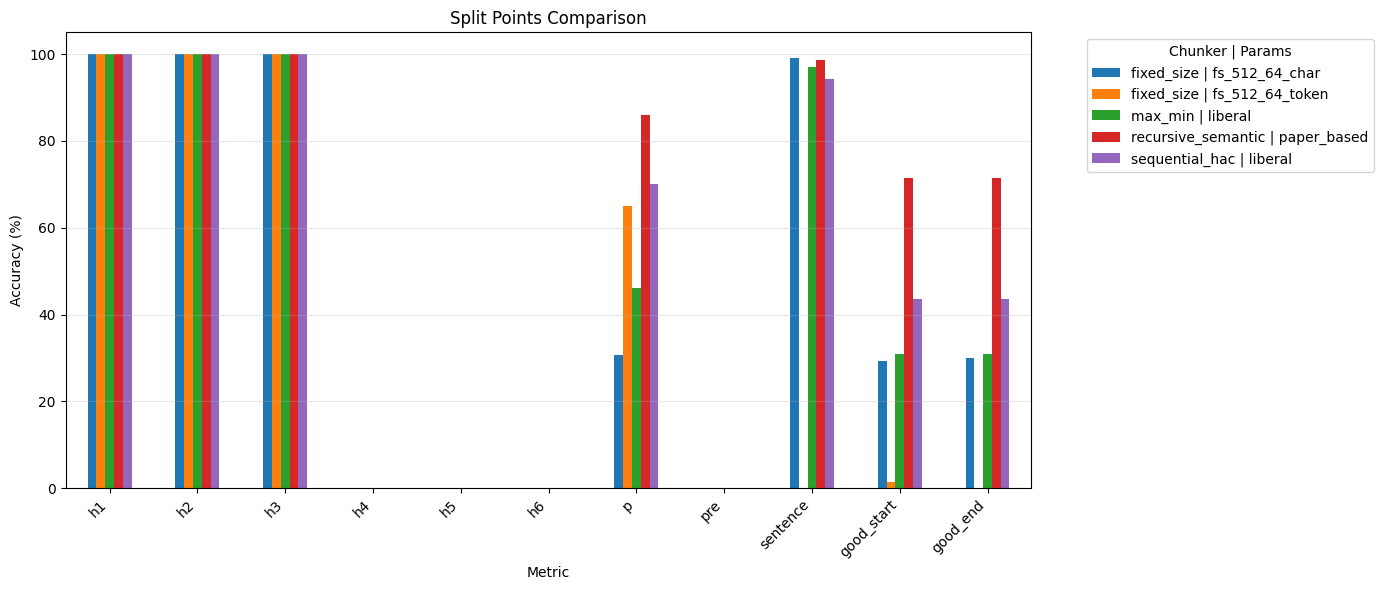

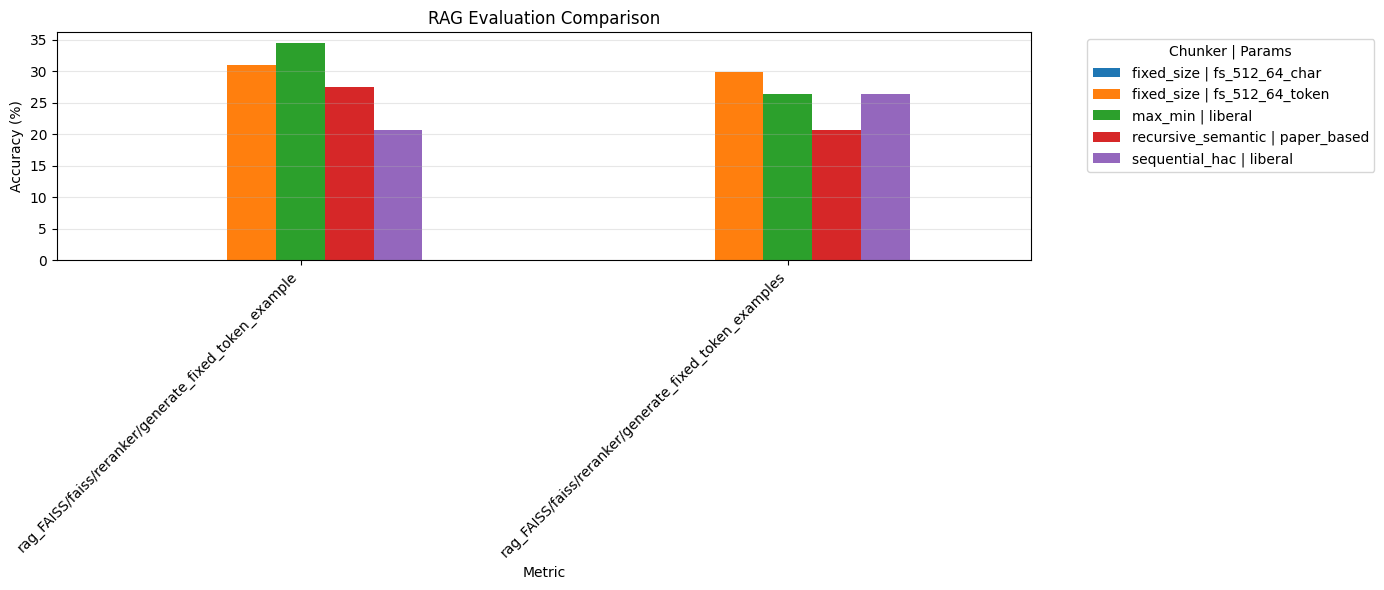


Zapisano: chunker_combined_analysis.csv


In [12]:
import json
from pathlib import Path
from typing import List, Dict, Set, Tuple, Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class ChunkerAnalyzer:
    """Klasa do analizy wyników chunkerów (chunker + params)"""

    ALLOWED_TAGS = {"h1", "h2", "h3", "h4", "h5", "h6", "p", "pre"}
    SPLITS = {'train', 'test', 'validation', 'example', 'examples'}

    def __init__(self, base_path: str = "data/analyze_split_points/literaryQA/default"):
        self.base_path = Path(base_path)
        self.rag_base_path = Path("data/evaluate_generator_result/literaryQA/default")

    # ------------------------------------------------------------
    # HELPERS
    # ------------------------------------------------------------

    def _iter_chunker_params(self) -> List[Tuple[str, str]]:
        """Zwraca listę (chunker, params)"""
        if not self.base_path.exists():
            return []

        result = []
        for chunker_dir in self.base_path.iterdir():
            if not chunker_dir.is_dir():
                continue

            for params_dir in chunker_dir.iterdir():
                if params_dir.is_dir():
                    result.append((chunker_dir.name, params_dir.name))

        return result

    def get_available_chunkers(self) -> List[Tuple[str, str]]:
        return self._iter_chunker_params()

    def get_available_splits(self, chunker: str, params: str) -> Set[str]:
        """Zwraca splity dla chunker+params"""
        splits = set()

        base = self.base_path / chunker / params / "analyze_split_point"
        html_path = base / "html_tag"
        sentence_path = base / "sentence"

        for path in [html_path, sentence_path]:
            if path.exists():
                splits.update([d.name for d in path.iterdir() if d.is_dir()])

        print(f"Dostępne splity dla ({chunker}, {params}): {splits}")
        return splits & self.SPLITS

    # ------------------------------------------------------------
    # LOAD DATA
    # ------------------------------------------------------------

    def load_html_tag_data(self, chunker: str, params: str, splits: List[str]) -> Dict:
        aggregated = {}

        for split in splits:
            file_path = (
                self.base_path / chunker / params / "analyze_split_point" / "html_tag" /
                split / "analyze_split_point.json"
            )

            if not file_path.exists():
                print(f"Brak: {file_path}")
                continue

            data = json.loads(file_path.read_text())

            for book_id, tags_data in data.items():
                if book_id not in aggregated:
                    aggregated[book_id] = {
                        tag: {"inside": 0, "splited": 0}
                        for tag in self.ALLOWED_TAGS
                    }

                    aggregated[book_id]["split_point"] = {
                        "good_start": 0,
                        "good_end": 0
                    }

                    aggregated[book_id]["total_chunks_analyzed"] = 0

                # Agreguj dane dla tagów HTML
                for tag in self.ALLOWED_TAGS:
                    if tag in tags_data:
                        aggregated[book_id][tag]["inside"] += (
                            tags_data[tag].get("inside", {}).get("num", 0)
                        )
                        aggregated[book_id][tag]["splited"] += (
                            tags_data[tag].get("splited", {}).get("num", 0)
                        )

                # split point metrics
                if "split_point" in tags_data:
                    aggregated[book_id]["split_point"]["good_start"] += (
                        tags_data["split_point"]
                        .get("good_start", {})
                        .get("num", 0)
                    )

                    aggregated[book_id]["split_point"]["good_end"] += (
                        tags_data["split_point"]
                        .get("good_end", {})
                        .get("num", 0)
                    )

                # TO MUSI BYĆ WEWNĄTRZ PĘTLI PO book_id!
                aggregated[book_id]["total_chunks_analyzed"] += (
                    tags_data.get("total_chunks_analyzed", 0)
                )

        return aggregated

    def load_sentence_data(self, chunker: str, params: str, splits: List[str]) -> Dict:
        aggregated = {}

        for split in splits:
            file_path = (
                self.base_path / chunker / params / "analyze_split_point" / "sentence" /
                split / "analyze_split_point.json"
            )

            if not file_path.exists():
                print(f"Brak: {file_path}")
                continue

            data = json.loads(file_path.read_text())

            for book_id, sent_data in data.items():
                if book_id not in aggregated:
                    aggregated[book_id] = {"total_correct": 0, "total_incorrect": 0}

                aggregated[book_id]["total_correct"] += sent_data.get("total_correct", 0)
                aggregated[book_id]["total_incorrect"] += sent_data.get("total_incorrect", 0)

        return aggregated

    # ------------------------------------------------------------
    # RAG EVALUATION DATA
    # ------------------------------------------------------------

    def _find_rag_paths(self, chunker: str, params: str) -> List[Path]:
        """Znajduje wszystkie ścieżki z generation_results.json dla danego chunkera"""
        chunker_path = self.rag_base_path / chunker / params
        
        if not chunker_path.exists():
            return []
        
        result_files = list(chunker_path.glob("**/generation_results.json"))
        return result_files

    def load_rag_data(self, chunker: str, params: str, splits: Optional[List[str]] = None) -> Dict[str, float]:
        """Wczytuje dane RAG i oblicza procent poprawnych odpowiedzi dla każdej konfiguracji"""
        rag_paths = self._find_rag_paths(chunker, params)
        
        if not rag_paths:
            print(f"  Brak wyników RAG dla ({chunker}, {params})")
            return {}
        
        results = {}
        
        for file_path in rag_paths:
            # Sprawdź split
            split_name = file_path.parent.name
            if splits and split_name not in splits:
                continue
            
            # Wczytaj dane
            try:
                data = json.loads(file_path.read_text())
            except Exception as e:
                print(f"  Błąd wczytywania {file_path}: {e}")
                continue
            
            # Oblicz procent poprawnych
            total = len(data)
            if total == 0:
                continue
            
            correct = sum(1 for q_data in data.values() if q_data.get("verdict") == "correct")
            percentage = (correct / total) * 100
            
            # Utwórz nazwę kolumny z części ścieżki
            # np. embed_name/search_name/reranker_name/generator_name
            parts = file_path.parts
            try:
                chunker_idx = parts.index(chunker)
                # Weź wszystko między chunker/params a split
                config_parts = parts[chunker_idx+2:-2]  # pomijamy chunker/params na początku i split/filename na końcu
                
                if len(config_parts) >= 8:
                    # Uproszczona nazwa: embed/search/reranker/generator
                    config_name = f"{config_parts[0]}/{config_parts[2]}/{config_parts[4]}/{config_parts[6]}"
                else:
                    config_name = "/".join(config_parts)
                
                col_name = f"rag_{config_name}_{split_name}"
                results[col_name] = percentage
                
            except (ValueError, IndexError) as e:
                print(f"  Błąd parsowania ścieżki {file_path}: {e}")
                continue
        
        return results

    # ------------------------------------------------------------
    # METRICS
    # ------------------------------------------------------------

    def calculate_percentages(self, html_data: Dict, sentence_data: Dict) -> Dict:

        # ------------------------------------------------------------
        # GLOBALNE LICZNIKI
        # ------------------------------------------------------------

        tag_totals = {
            tag: {
                "inside": 0,
                "splited": 0
            }
            for tag in self.ALLOWED_TAGS
        }

        sentence_correct = 0
        sentence_incorrect = 0

        total_good_start = 0
        total_good_end = 0
        total_chunks_analyzed = 0

        # ------------------------------------------------------------
        # HTML TAGS + SPLIT POINTS
        # ------------------------------------------------------------

        for _, tags_data in html_data.items():

            # split point
            total_good_start += (
                tags_data
                .get("split_point", {})
                .get("good_start", 0)
            )

            total_good_end += (
                tags_data
                .get("split_point", {})
                .get("good_end", 0)
            )

            total_chunks_analyzed += (
                tags_data.get("total_chunks_analyzed", 0)
            )

            # html tags
            for tag in self.ALLOWED_TAGS:

                tag_totals[tag]["inside"] += (
                    tags_data[tag]["inside"]
                )

                tag_totals[tag]["splited"] += (
                    tags_data[tag]["splited"]
                )

        # ------------------------------------------------------------
        # SENTENCE
        # ------------------------------------------------------------

        for _, sent_data in sentence_data.items():

            sentence_correct += (
                sent_data.get("total_correct", 0)
            )

            sentence_incorrect += (
                sent_data.get("total_incorrect", 0)
            )

        # ------------------------------------------------------------
        # PROCENTY
        # ------------------------------------------------------------

        result = {}

        # html tags
        for tag in self.ALLOWED_TAGS:

            inside = tag_totals[tag]["inside"]
            splited = tag_totals[tag]["splited"]

            total = inside + splited

            if total > 0:
                result[tag] = (
                    inside / total
                ) * 100
            else:
                result[tag] = np.nan

        # sentence
        sentence_total = (
            sentence_correct + sentence_incorrect
        )

        if sentence_total > 0:
            result["sentence"] = (
                sentence_correct / sentence_total
            ) * 100
        else:
            result["sentence"] = np.nan

        # good_start
        if total_chunks_analyzed > 0:
            result["good_start"] = (
                total_good_start / total_chunks_analyzed
            ) * 100

            result["good_end"] = (
                total_good_end / total_chunks_analyzed
            ) * 100
        else:
            result["good_start"] = np.nan
            result["good_end"] = np.nan

        # ------------------------------------------------------------
        # SPLIT POINT BREAK
        # ------------------------------------------------------------

        total_html_splited = 0

        for tag in self.ALLOWED_TAGS:
            total_html_splited += (
                tag_totals[tag]["splited"]
            )

        return result

    # ------------------------------------------------------------
    # MAIN ANALYSIS
    # ------------------------------------------------------------

    def analyze(
        self,
        chunker_params: Optional[List[Tuple[str, str]]] = None,
        splits: Optional[List[str]] = None
    ) -> pd.DataFrame:

        if chunker_params is None:
            chunker_params = self.get_available_chunkers()

        if not chunker_params:
            print("Brak chunkerów!")
            return pd.DataFrame()

        results = []

        for chunker, params in chunker_params:
            print(f"\nAnaliza: {chunker} | {params}")

            available_splits = self.get_available_splits(chunker, params)

            splits_to_use = (
                list(available_splits)
                if splits is None
                else [s for s in splits if s in available_splits]
            )

            if not splits_to_use:
                print("  brak splitów")
                continue

            html_data = self.load_html_tag_data(chunker, params, splits_to_use)
            sentence_data = self.load_sentence_data(chunker, params, splits_to_use)

            row = self.calculate_percentages(html_data, sentence_data)
            row["chunker"] = chunker
            row["params"] = params

            results.append(row)

        if not results:
            return pd.DataFrame()

        df = pd.DataFrame(results)
        df = df.set_index(["chunker", "params"])

        return df

    def analyze_rag(
        self,
        chunker_params: Optional[List[Tuple[str, str]]] = None,
        splits: Optional[List[str]] = None
    ) -> pd.DataFrame:
        """Tworzy DataFrame z wynikami RAG evaluation"""
        
        if chunker_params is None:
            chunker_params = self.get_available_chunkers()

        if not chunker_params:
            print("Brak chunkerów!")
            return pd.DataFrame()

        results = []

        for chunker, params in chunker_params:
            print(f"\nAnaliza RAG: {chunker} | {params}")

            rag_data = self.load_rag_data(chunker, params, splits)
            
            if not rag_data:
                continue
            
            row = rag_data.copy()
            row["chunker"] = chunker
            row["params"] = params

            results.append(row)

        if not results:
            print("Brak wyników RAG!")
            return pd.DataFrame()

        df = pd.DataFrame(results)
        df = df.set_index(["chunker", "params"])

        return df

    def analyze_combined(
        self,
        chunker_params: Optional[List[Tuple[str, str]]] = None,
        splits: Optional[List[str]] = None
    ) -> pd.DataFrame:
        """Łączy analizę split points i RAG evaluation"""
        
        df_split = self.analyze(chunker_params, splits)
        df_rag = self.analyze_rag(chunker_params, splits)
        
        if df_split.empty and df_rag.empty:
            return pd.DataFrame()
        
        if df_split.empty:
            return df_rag
        
        if df_rag.empty:
            return df_split
        
        # Połącz oba DataFrames
        df_combined = df_split.join(df_rag, how='outer')
        
        return df_combined


# ============================================================
# WIZUALIZACJA
# ============================================================

def plot_comparison(df: pd.DataFrame, title: str = "Chunker comparison", 
                    columns: Optional[List[str]] = None):
    if df.empty:
        print("Brak danych")
        return

    fig, ax = plt.subplots(figsize=(14, 6))

    df_plot = df.copy()
    
    # Wybierz tylko określone kolumny jeśli podano
    if columns:
        df_plot = df_plot[[col for col in columns if col in df_plot.columns]]
    
    df_plot.index = [f"{c} | {p}" for c, p in df_plot.index]

    df_plot.T.plot(kind="bar", ax=ax)

    ax.set_title(title)
    ax.set_ylabel("Accuracy (%)")
    ax.set_xlabel("Metric")
    ax.grid(axis="y", alpha=0.3)

    ax.legend(title="Chunker | Params", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# ============================================================
# PRZYKŁAD UŻYCIA
# ============================================================

if __name__ == "__main__":
    analyzer = ChunkerAnalyzer()

    available = analyzer.get_available_chunkers()
    print("Dostępne (chunker, params):", available)

    print("\n" + "=" * 80)
    print("SPLIT POINTS ANALYSIS")
    print("=" * 80)

    df_split = analyzer.analyze(splits=["example"])
    print(df_split.round(2))

    print("\n" + "=" * 80)
    print("RAG EVALUATION ANALYSIS")
    print("=" * 80)

    df_rag = analyzer.analyze_rag()
    print(df_rag.round(2))

    print("\n" + "=" * 80)
    print("COMBINED ANALYSIS")
    print("=" * 80)

    df_combined = analyzer.analyze_combined()
    print(df_combined.round(2))

    if not df_combined.empty:
        # Wykres dla split points
        split_cols = ['h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'p', 'pre', 'sentence', 'good_start', 'good_end']
        split_cols = [col for col in split_cols if col in df_combined.columns]
        if split_cols:
            plot_comparison(df_combined, "Split Points Comparison", columns=split_cols)
        
        # Wykres dla RAG results
        rag_cols = [col for col in df_combined.columns if col.startswith('rag_')]
        if rag_cols:
            plot_comparison(df_combined, "RAG Evaluation Comparison", columns=rag_cols)

        # Zapisz do CSV
        df_combined.to_csv("chunker_combined_analysis.csv")
        print("\nZapisano: chunker_combined_analysis.csv")

In [11]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


ALLOWED_COLUMNS = ["h1", "h2", "h3", "h4", "h5", "h6", "p", "pre", 'sentence', 'good_start', 'good_end']


# ============================================================
# CONFIG
# ============================================================

@dataclass
class ImportanceConfig:
    """
    Konfiguracja modelu importance.
    Dzięki temu łatwo później podmienić model / preprocessing.
    """
    model_factory: Callable[[], object]
    use_scaling: bool = True
    nan_strategy: str = "median"


DEFAULT_CONFIG = ImportanceConfig(
    model_factory=lambda: LogisticRegression(
        max_iter=5000,
        random_state=42,
    )
)


# ============================================================
# CORE
# ============================================================

class FeatureImportanceAnalyzer:
    def __init__(
        self,
        df_split: pd.DataFrame,
        df_rag: pd.DataFrame,
        config: ImportanceConfig = DEFAULT_CONFIG,
    ):
        self.df_split = df_split.copy()
        self.df_rag = df_rag.copy()
        self.config = config

        self._validate_inputs()
        self.X = self._prepare_features()

    def _validate_inputs(self) -> None:
        required_index_names = {"chunker", "params"}

        split_index_names = set(self.df_split.index.names)
        rag_index_names = set(self.df_rag.index.names)

        if split_index_names != required_index_names:
            raise ValueError(
                f"df_split musi mieć indeksy: {required_index_names}, "
                f"aktualnie: {split_index_names}"
            )

        if rag_index_names != required_index_names:
            raise ValueError(
                f"df_rag musi mieć indeksy: {required_index_names}, "
                f"aktualnie: {rag_index_names}"
            )

    def _prepare_features(self) -> pd.DataFrame:
        """
        Zachowujemy tylko kolumny z ALLOWED_COLUMNS
        i pilnujemy odpowiedniej kolejności.
        """
        existing_columns = [
            col for col in ALLOWED_COLUMNS
            if col in self.df_split.columns
        ]

        if not existing_columns:
            raise ValueError(
                "Brak kolumn z ALLOWED_COLUMNS w df_split."
            )

        return self.df_split[existing_columns]

    def _build_pipeline(self) -> Pipeline:
        steps = [
            ("imputer", SimpleImputer(strategy=self.config.nan_strategy)),
        ]

        if self.config.use_scaling:
            steps.append(("scaler", StandardScaler()))

        steps.append(("model", self.config.model_factory()))

        return Pipeline(steps)

    @staticmethod
    def _prepare_target(y: pd.Series) -> pd.Series:
        """
        LogisticRegression wymaga targetu klasowego.
        Zakładam tutaj binaryzację:
        > mediany => 1
        <= mediany => 0

        Łatwo później zmienić strategię.
        """
        threshold = y.median()
        return (y > threshold).astype(int)

    def calculate_importance(self) -> dict[str, pd.Series]:
        results: dict[str, pd.Series] = {}

        for target_col in self.df_rag.columns:
            y_raw = self.df_rag[target_col]

            # wspólny index
            common_idx = self.X.index.intersection(y_raw.index)

            X = self.X.loc[common_idx]
            y = y_raw.loc[common_idx]

            # usuwamy NaN z y
            valid_mask = y.notna()

            X = X.loc[valid_mask]
            y = y.loc[valid_mask]

            # binary target
            y_binary = self._prepare_target(y)

            pipeline = self._build_pipeline()
            pipeline.fit(X, y_binary)

            model = pipeline.named_steps["model"]

            # współczynniki regresji logistycznej
            coefficients = model.coef_[0]

            # sklearn >= 1.0
            feature_names = pipeline[:-1].get_feature_names_out()

            importance = pd.Series(
                coefficients,
                index=feature_names,
                name=target_col,
            )

            # sort po absolute importance
            importance = importance.reindex(ALLOWED_COLUMNS)

            results[target_col] = importance

        return results

    @staticmethod
    def print_importance(results: dict[str, pd.Series]) -> None:
        """
        Jeden print per kolumna z df_rag.
        """
        for target_col, importance in results.items():
            print("=" * 80)
            print(f"RAG COLUMN: {target_col}")
            print("=" * 80)

            for feature_name, weight in importance.items():
                print(f"{feature_name:<5} -> {weight:>12.6f}")

            print("\n")


# ============================================================
# USAGE
# ============================================================

analyzer = FeatureImportanceAnalyzer(
    df_split=df_split,
    df_rag=df_rag,
)

results = analyzer.calculate_importance()

analyzer.print_importance(results)

RAG COLUMN: rag_FAISS/faiss/reranker/generate_fixed_token_example
h1    ->     0.000000
h2    ->     0.000000
h3    ->     0.000000
h4    ->          nan
h5    ->          nan
h6    ->          nan
p     ->    -0.634328
pre   ->          nan
sentence ->    -0.296568
good_start ->    -0.470206
good_end ->    -0.468602


RAG COLUMN: rag_FAISS/faiss/reranker/generate_fixed_token_examples
h1    ->     0.000000
h2    ->     0.000000
h3    ->     0.000000
h4    ->          nan
h5    ->          nan
h6    ->          nan
p     ->     0.082278
pre   ->          nan
sentence ->    -0.661147
good_start ->    -0.460139
good_end ->    -0.466903




/home/mahuk/chunking-thesis/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['h4' 'h5' 'h6' 'pre']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/mahuk/chunking-thesis/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['h4' 'h5' 'h6' 'pre']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
